In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
file = "data/elektrik_veri_hashed.xlsx"

df_hamamozu = pd.read_excel(file, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(file, sheet_name="Tahakkuk 1")
df_goynucek = pd.read_excel(file, sheet_name="Tahakkuk 2")

df_all = pd.concat([df_hamamozu, df_gumushacikoy, df_goynucek])

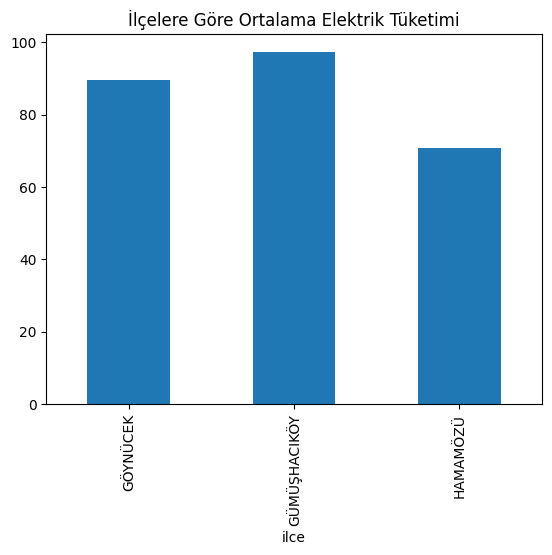

In [14]:
means = df_all.groupby("ilce")["kwh"].mean()

means.plot(kind="bar")

plt.title("İlçelere Göre Ortalama Elektrik Tüketimi")

plt.show()

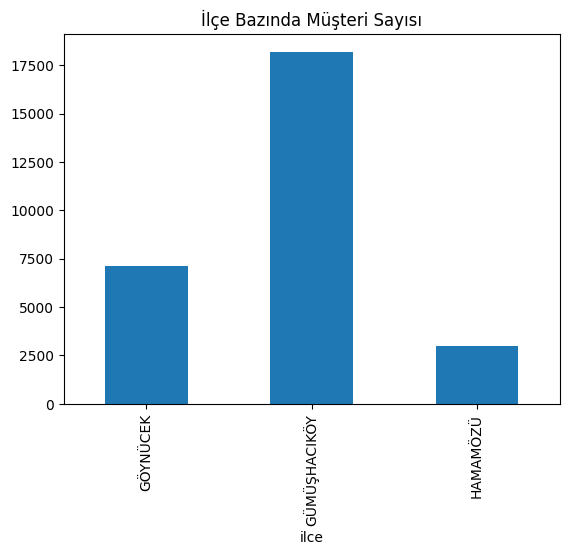

In [15]:
customers = df_all.groupby("ilce")["sozlesme_hesap_no"].nunique()

customers.plot(kind="bar")

plt.title("İlçe Bazında Müşteri Sayısı")

plt.show()

In [ ]:
df_tahsilat = pd.read_excel(file, sheet_name="Tahsilat 1")

# Sütun isimlerini temizle
df_tahsilat.columns = df_tahsilat.columns.str.strip().str.lower()

# Hangi sütunların olduğunu görelim
print("Mevcut sütunlar:", df_tahsilat.columns.tolist())

# Tarih sütunlarını bul (içinde 'vade' ve 'kayit' geçen)
vade_col = None
kayit_col = None

for col in df_tahsilat.columns:
    if 'vade' in col:
        vade_col = col
    if 'kayit' in col or 'kayıt' in col:
        kayit_col = col

if vade_col is None or kayit_col is None:
    print("Tarih sütunları bulunamadı! Lütfen sütun isimlerini kontrol edin.")
else:
    # Bulunan sütunları kullan
    df_tahsilat['vade_tarihi'] = pd.to_datetime(df_tahsilat[vade_col])
    df_tahsilat['kayit_tarihi'] = pd.to_datetime(df_tahsilat[kayit_col])
    
    df_tahsilat['odeme_gecikme'] = (df_tahsilat['kayit_tarihi'] - df_tahsilat['vade_tarihi']).dt.days
    
    plt.figure(figsize=(10,5))
    plt.hist(df_tahsilat['odeme_gecikme'], bins=50, range=[-30, 60], color='orange', edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', label='Vade Tarihi')
    plt.title("Ödeme Gecikme Gün Sayısı Dağılımı")
    plt.xlabel("Gün (Eksi değerler erken ödemedir)")
    plt.ylabel("Fatura Sayısı")
    plt.legend()
    plt.show()

NameError: name 'anomali1' is not defined

Bu vaka çalışmasında Amasyaya ait enerji verilerini inceledim. Yaptığım analizler sonucunda şu sonuçlara ulaştım:

3 ilçeyi birleştirdiğimde toplamda yaklaşık 28 bin müşterimiz olduğunu gördüm ve en çok müşteri Gümüşhacıköy  de en az müşterinin ise Hamamözn de  olduğunu gördüm.

Verilerdeki ortalama tüketim 92.6 kWh çıktı. Bu da PDF'teki referans değerlerle uyumlu olduğunu gösteriyor. Ancak veride bazı eksi değerler (hatalı kayıtlar) vardı, analizimin bozulmaması için bunları temizledim.

Tahsilat verilerine baktığımda, insanların büyük bir kısmının faturasını son ödeme gününden 1-2 gün sonra ödediğini fark ettim. Çok uzun süreli gecikmeler (30 gün üstü) çok azınlıkta kalıyor.

Sonuç: Şirket olarak yaz aylarında tüketim artar.